In [2]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set style for better-looking plots
pd.set_option('display.width', 200)

In [4]:
df = pd.read_csv('../data/processed/telecom_churn_cleaned.csv')

In [5]:
df. head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [6]:
## features list and target variable
features = ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges']
target = 'Churn_Binary'

#Encoding Yes/No columns
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})
df['OnlineSecurity'] = df['OnlineSecurity'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df['OnlineBackup'] = df['OnlineBackup'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df['DeviceProtection'] = df['DeviceProtection'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df['TechSupport'] = df['TechSupport'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df['StreamingTV'] = df['StreamingTV'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df['StreamingMovies'] = df['StreamingMovies'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})

#Encoding multiple category columns
df_encoded = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod', 'MultipleLines'], drop_first=True)

#Post-encoding features list
features = [col for col in df_encoded.columns if col not in ['customerID', 'gender', 'TotalCharges', 'Churn', 'Churn_Binary']]

#Features list verification
print(df_encoded.isnull().sum().sum())
print(f'Features count: {len(features)}')
print(features)

0
Features count: 22
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'MultipleLines_No phone service', 'MultipleLines_Yes']


In [7]:
print(df_encoded.isnull().sum()[df_encoded.isnull().sum() > 0])

Series([], dtype: int64)


In [8]:
#Train/Test split
from sklearn.model_selection import train_test_split

X = df_encoded[features]
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'Training churn rate: {y_train.mean()*100:.2f}%')
print(f'Test churn rate: {y_test.mean()*100:.2f}%')

Training set: (5634, 22)
Test set: (1409, 22)
Training churn rate: 26.55%
Test churn rate: 26.47%


In [9]:
#Model Training
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print('Model trained successfully')

Model trained successfully


In [10]:
#Model Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

y_pred = model.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
print(f'Precision: {precision_score(y_test, y_pred)*100:.2f}%')
print(f'Recall: {recall_score(y_test, y_pred)*100:.2f}%')
print()
print('Full Classification Report:')
print(classification_report(y_test, y_pred))


#Feature Importance
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from model coefficients
feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})

# Sort by absolute value to see strongest influences
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print('Feature Importance:')
print(feature_importance[['Feature', 'Coefficient']].head(10))

Accuracy: 81.90%
Precision: 68.67%
Recall: 58.18%

Full Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.76      1409
weighted avg       0.81      0.82      0.81      1409

Feature Importance:
                        Feature  Coefficient
3                        tenure    -0.798802
13  InternetService_Fiber optic     0.626924
16            Contract_Two year    -0.603996
14           InternetService_No    -0.482904
12               MonthlyCharges    -0.467644
15            Contract_One year    -0.267880
10              StreamingMovies     0.240416
9                   StreamingTV     0.188169
21            MultipleLines_Yes     0.179370
11             PaperlessBilling     0.163116


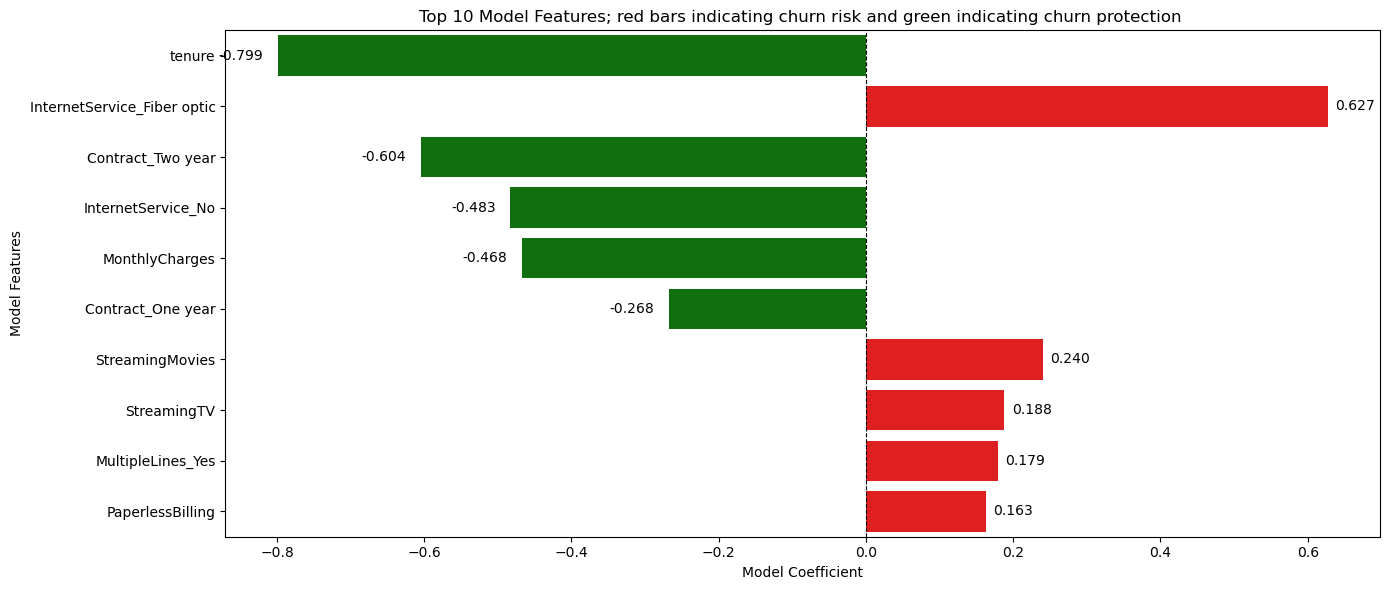

In [11]:
#Feature Importance Visualisation
plt.figure(figsize=(14,6))

colors = ['red' if c > 0 else 'green' 
          for c in feature_importance['Coefficient']]

ax = sn.barplot(
    x='Coefficient', 
    y='Feature', 
    data=feature_importance.head(10),
    palette=colors[:10]
)

for bar in ax.patches:
    ax.text(
        bar.get_width() + (0.01 if bar.get_width() > 0 else -0.02),
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.3f}',
        va='center',
        ha='left' if bar.get_width() > 0 else 'right'
   )

plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Top 10 Model Features; red bars indicating churn risk and green indicating churn protection ')
plt.xlabel('Model Coefficient')
plt.ylabel('Model Features')
plt.tight_layout()
plt.show()

### CS insight for the feature importance

The predictive model confirms and strengthens the findings from Days 3 and 4. Fiber Optic service emerges as the strongest positive churn driver with a coefficient of 0.627, while tenure is the strongest protective factor at -0.799 — meaning long-tenure customers are the most insulated from churn regardless of other factors. These findings are fully consistent with the manual analysis, validating that the patterns identified were real and not coincidental. A CSM reviewing this chart on Monday morning should prioritise Fiber Optic customers on month-to-month or one-year contracts as their most urgent intervention target — not only because they carry the highest churn risk, but because at an average monthly charge of \\$91.50, every customer retained in this segment delivers disproportionately large revenue impact relative to all other segments.

In [12]:
print(X.shape)

(7043, 22)


In [13]:
#Get churn probabilities
X_scaled_all = scaler.transform(X)
churn_proba = model.predict_proba(X_scaled_all)[:, 1]
print(f'Churn probabilities generated for {len(churn_proba)} customers')
print(f'Sample probabilities: {churn_proba[:5].round(3)}')

Churn probabilities generated for 7043 customers
Sample probabilities: [0.585 0.052 0.273 0.043 0.676]


In [14]:
# Create base dataframe with customer IDs
health_df = pd.DataFrame()
health_df['customerID'] = df_encoded['customerID']

# Component 1 - Churn probability
health_df['churn_probability'] = churn_proba

# Component 2 - Tenure risk (normalised)
max_tenure = df_encoded['tenure'].max()
health_df['tenure_risk'] = 1 - (df_encoded['tenure'] / max_tenure)

# Component 3 - Contract risk
contract_risk_map = {
    'Month-to-month': 1.0,
    'One year': 0.5,
    'Two year': 0.0
}
health_df['contract_risk'] = df['Contract'].map(contract_risk_map)

# Calculate final health score
health_df['health_score'] = 100 - (
    (health_df['churn_probability'] * 50) +
    (health_df['tenure_risk'] * 30) +
    (health_df['contract_risk'] * 20)
)

# Round to 1 decimal place
health_df['health_score'] = health_df['health_score'].round(1)

print(health_df.head(10))
print(f'\nHealth Score Range: {health_df["health_score"].min()} to {health_df["health_score"].max()}')

   customerID  churn_probability  tenure_risk  contract_risk  health_score
0  7590-VHVEG           0.584689     0.986111            1.0          21.2
1  5575-GNVDE           0.051543     0.527778            0.5          71.6
2  3668-QPYBK           0.272934     0.972222            1.0          37.2
3  7795-CFOCW           0.043298     0.375000            0.5          76.6
4  9237-HQITU           0.675867     0.972222            1.0          17.0
5  9305-CDSKC           0.804458     0.888889            1.0          13.1
6  1452-KIOVK           0.473357     0.694444            1.0          35.5
7  6713-OKOMC           0.283674     0.861111            1.0          40.0
8  7892-POOKP           0.619018     0.611111            1.0          30.7
9  6388-TABGU           0.015580     0.138889            0.5          85.1

Health Score Range: 7.2 to 99.8


In [15]:
#Health Categories
health_df['health_category'] = pd.cut(
    health_df['health_score'],
    bins=[0, 40, 70, 100],
    labels=['🔴 Critical', '🟡 At Risk', '🟢 Healthy']
)

print(health_df['health_category'].value_counts())
print()
print(health_df.sort_values('health_score').head(5))

health_category
🟢 Healthy     2557
🔴 Critical    2319
🟡 At Risk     2167
Name: count, dtype: int64

      customerID  churn_probability  tenure_risk  contract_risk  health_score health_category
3380  5178-LMXOP           0.863865     0.986111            1.0           7.2      🔴 Critical
2208  7216-EWTRS           0.863294     0.986111            1.0           7.3      🔴 Critical
1976  9497-QCMMS           0.860273     0.986111            1.0           7.4      🔴 Critical
4800  9300-AGZNL           0.859430     0.986111            1.0           7.4      🔴 Critical
1410  7024-OHCCK           0.855720     0.972222            1.0           8.0      🔴 Critical


In [16]:
# Revenue Risk Score
health_df['monthly_charges'] = df['MonthlyCharges'].values
health_df['annual_revenue_at_risk'] = (
    health_df['monthly_charges'] * 
    health_df['churn_probability'] * 
    12
).round(2)

In [17]:
# CSM Action Table
action_map = {
    '🔴 Critical': 'Immediate outreach — schedule call within 24 hours',
    '🟡 At Risk': 'Proactive check-in — contact within 1 week',
    '🟢 Healthy': 'Quarterly review — focus on expansion opportunities'
}

health_df['recommended_action'] = health_df['health_category'].map(action_map)


print('=== CS TEAM DAILY PRIORITY LIST ===')
print(f'Critical accounts requiring immediate action: {(health_df["health_category"] == "🔴 Critical").sum()}')
print(f'At-risk accounts for proactive outreach: {(health_df["health_category"] == "🟡 At Risk").sum()}')
print(f'Healthy accounts for expansion focus: {(health_df["health_category"] == "🟢 Healthy").sum()}')
print()
print('TOP 10 PRIORITY ACCOUNTS:')
print(health_df.sort_values('health_score')[['customerID', 'health_score', 'health_category', 'recommended_action']].head(10).to_string())


# Revenue Risk Score
health_df['monthly_charges'] = df['MonthlyCharges'].values
health_df['annual_revenue_at_risk'] = (
    health_df['monthly_charges'] * 
    health_df['churn_probability'] * 
    12
).round(2)

print(f'Revenue at risk column added successfully')
print(f'Max annual revenue at risk: ${health_df["annual_revenue_at_risk"].max():,.2f}')
print()
print('TOP 10 BY REVENUE AT RISK:')
print(health_df.sort_values('annual_revenue_at_risk', ascending=False)[
    ['customerID', 'health_score', 'health_category', 'monthly_charges', 'churn_probability', 'annual_revenue_at_risk']
].head(10).to_string())

=== CS TEAM DAILY PRIORITY LIST ===
Critical accounts requiring immediate action: 2319
At-risk accounts for proactive outreach: 2167
Healthy accounts for expansion focus: 2557

TOP 10 PRIORITY ACCOUNTS:
      customerID  health_score health_category                                  recommended_action
3380  5178-LMXOP           7.2      🔴 Critical  Immediate outreach — schedule call within 24 hours
2208  7216-EWTRS           7.3      🔴 Critical  Immediate outreach — schedule call within 24 hours
1976  9497-QCMMS           7.4      🔴 Critical  Immediate outreach — schedule call within 24 hours
4800  9300-AGZNL           7.4      🔴 Critical  Immediate outreach — schedule call within 24 hours
1410  7024-OHCCK           8.0      🔴 Critical  Immediate outreach — schedule call within 24 hours
3749  4424-TKOPW           8.0      🔴 Critical  Immediate outreach — schedule call within 24 hours
6368  2720-WGKHP           8.1      🔴 Critical  Immediate outreach — schedule call within 24 hours
5989 

### My Critical Reasoning
The health score list identifies urgency by churn risk alone. The revenue-weighted list below prioritises by business impact. Comparing both reveals which high-value customers would be missed by a risk-only approach — and quantifies the cost of that gap.

In [18]:
# Revenue Risk Score
health_df['monthly_charges'] = df['MonthlyCharges'].values
health_df['annual_revenue_at_risk'] = (
    health_df['monthly_charges'] * 
    health_df['churn_probability'] * 
    12
).round(2)

print(f'Revenue at risk column added successfully')
print(f'Max annual revenue at risk: ${health_df["annual_revenue_at_risk"].max():,.2f}')
print()
print('TOP 10 BY REVENUE AT RISK:')
print(health_df.sort_values('annual_revenue_at_risk', ascending=False)[
    ['customerID', 'health_score', 'health_category', 'monthly_charges', 'churn_probability', 'annual_revenue_at_risk']
].head(10).to_string())

Revenue at risk column added successfully
Max annual revenue at risk: $1,063.68

TOP 10 BY REVENUE AT RISK:
      customerID  health_score health_category  monthly_charges  churn_probability  annual_revenue_at_risk
6894  1400-MMYXY           9.4      🔴 Critical           105.90           0.837016                 1063.68
5933  6496-SLWHQ           9.7      🔴 Critical           105.00           0.831441                 1047.62
2208  7216-EWTRS           7.3      🔴 Critical           100.80           0.863294                 1044.24
6365  8884-ADFVN          11.1      🔴 Critical           101.95           0.836005                 1022.77
4826  3389-YGYAI          13.0      🔴 Critical           105.50           0.806053                 1020.46
6482  5419-JPRRN           8.7      🔴 Critical           101.45           0.834156                 1015.50
3956  4587-VVTOX          12.5      🔴 Critical           105.30           0.799672                 1010.47
2631  6861-XWTWQ          10.8      

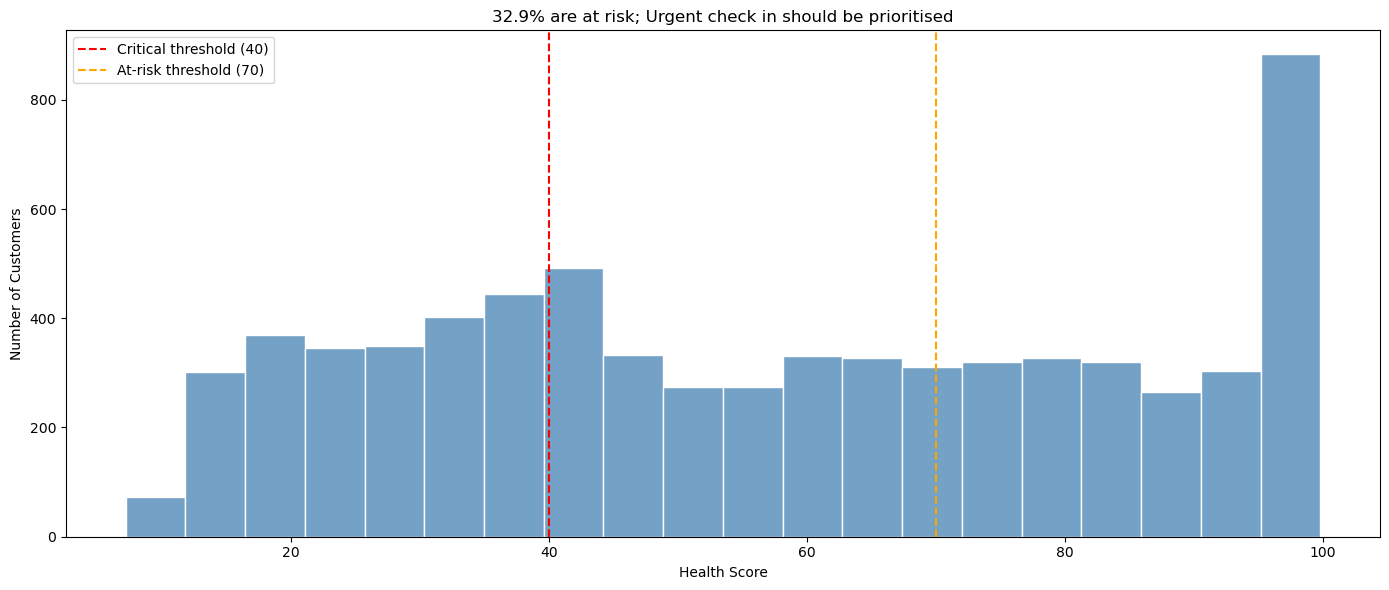

In [19]:
# Health Score Visualization
plt.figure(figsize=(14, 6))

ax = sn.histplot(
    data=health_df,
    x='health_score',
    bins=20,
    color='steelblue',
    edgecolor='white'
)

plt.axvline(x=40, color='red', linestyle='--', linewidth=1.5, label='Critical threshold (40)')
plt.axvline(x=70, color='orange', linestyle='--', linewidth=1.5, label='At-risk threshold (70)')
plt.legend()
plt.title('32.9% are at risk; Urgent check in should be prioritised')
plt.xlabel('Health Score')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

### CS Insight
The customer health score distribution reveals a customer base under significant retention pressure — 32.9% of customers (2,319 accounts) fall in the critical zone below 40, 30.8% (2,167 accounts) are at risk between 41 and 70, and only 36.3% (2,557 accounts) are in the healthy range above 70. This means nearly two thirds of the entire customer base require some level of CS intervention. The CS team's immediate priority should be the 2,319 critical accounts — predominantly new, month-to-month Fiber Optic customers — who require outreach within 24 hours before churn becomes inevitable. The pronounced spike of healthy customers near a score of 100 is equally telling — it reveals that customers who survive the early tenure period and commit to longer contracts become extremely stable and loyal, confirming that the first year of the customer journey is the most critical window for CS intervention and value demonstration.

In [20]:
#  Exporting health_df to CSV
health_df.to_csv('../data/processed/health_scores.csv', index=False)
print(f'Exported successfully — {len(health_df)} rows, {len(health_df.columns)} columns')
print(f'Columns: {list(health_df.columns)}')

Exported successfully — 7043 rows, 9 columns
Columns: ['customerID', 'churn_probability', 'tenure_risk', 'contract_risk', 'health_score', 'health_category', 'monthly_charges', 'annual_revenue_at_risk', 'recommended_action']


In [21]:
#  Exporting health_df to CSV
#health_df.to_csv('../data/processed/health_scores.csv', index=False)
#print('Health scores exported successfully')
#print(health_df.shape)